# Sequential & Collaborative Agents란?

**Sequential Agent**와 **Collaborative Agent**는 여러 에이전트가 함께 작업하는 Multi-Agent 패턴입니다.

## Sequential Agent (순차적 에이전트)

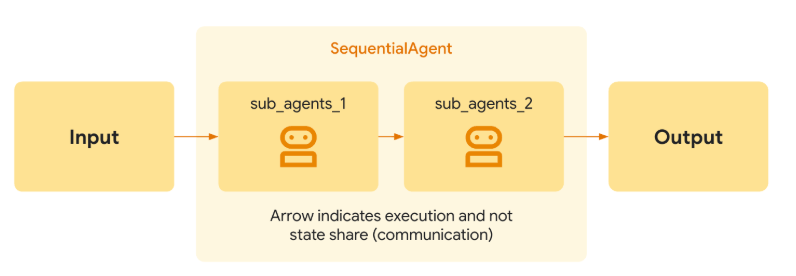

### 핵심 특징
1. **파이프라인 방식** (Pipeline Pattern)
   - 에이전트들이 정해진 순서대로 실행
   - 이전 에이전트의 출력이 다음 에이전트의 입력
   
2. **단계별 처리** (Step-by-Step Processing)
   - 각 단계가 명확하게 구분됨
   - 데이터가 단계를 거치며 변환/개선

3. **고정된 워크플로우** (Fixed Workflow)
   - 실행 순서가 미리 정해짐
   - 예측 가능한 흐름

### 작동 방식
```
입력 → Agent A → Agent B → Agent C → 출력
      (단계1)   (단계2)   (단계3)
```

## Collaborative Agent (협업 에이전트)

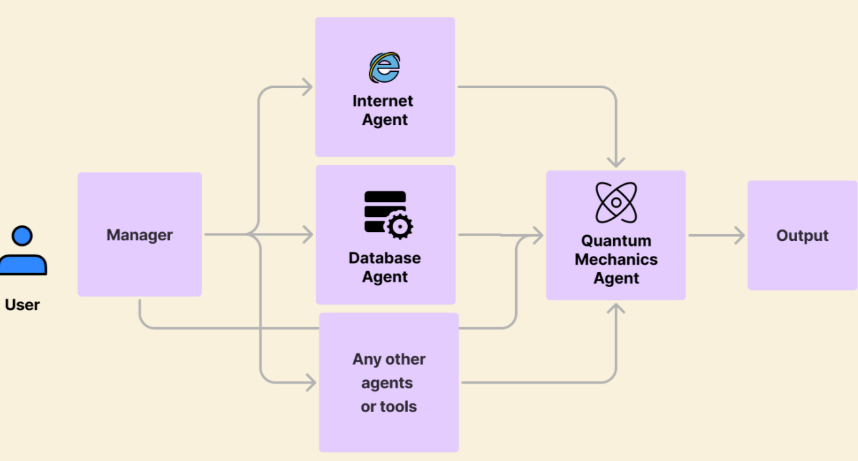

### 핵심 특징
1. **병렬 실행** (Parallel Execution)
   - 여러 에이전트가 동시에 작업
   - 서로 의존하지 않고 독립적으로 실행

2. **결과 집계** (Result Aggregation)
   - 각 에이전트의 결과를 수집
   - 통합 에이전트가 최종 결과 생성

3. **동등한 관계** (Equal Partnership)
   - 계층 구조 없이 수평적 협업
   - 각자의 전문성 발휘

### 작동 방식
```
        입력
         ↓
    ┌────┼────┐
    ↓    ↓    ↓
Agent A  B  C (병렬 실행)
    ↓    ↓    ↓
    └────┼────┘
         ↓
   결과 통합
         ↓
       출력
```

# Multi Agents - 코드 리뷰 시스템
LangGraph를 활용하여 여러 에이전트가 병렬로 실행되고 결과를 집계하는 코드 리뷰 시스템을 구현합니다.



### 이 예제가 Sequential & Collaborative Agent인 이유

**코드 리뷰 시스템**은 두 패턴을 결합한 사례입니다:

#### Collaborative 측면
1. **병렬 실행**: 4개의 리뷰 에이전트가 동시에 코드 분석
   - 코드 분석 에이전트
   - 버그 검사 에이전트
   - 스타일 검사 에이전트
   - 성능 분석 에이전트

2. **독립적 작업**: 각 에이전트가 자신의 관점에서 독립적으로 리뷰

3. **결과 집계**: 통합 리포트 에이전트가 모든 리뷰 결과를 종합

#### Sequential 측면
1. **순차적 흐름**: 병렬 리뷰 → 결과 수집 → 통합 리포트
2. **단계별 처리**: 개별 분석 후 통합 단계

### 장점

**Collaborative의 장점**:
- 빠른 실행 (병렬 처리)
- 다양한 관점 확보
- 확장성 (에이전트 추가/제거 쉬움)

**Sequential의 장점**:
- 명확한 프로세스
- 단계별 추적 가능
- 순차적 개선

### vs. 다른 패턴

| 패턴 | 실행 방식 | 관계 |
|------|----------|------|
| **Hierarchical** | 1개 선택 실행 | 계층적 |
| **Collaborative** | 병렬 실행 | 수평적 |
| **Sequential** | 순차 실행 | 파이프라인 |
| **Supervisor** | 순차 조율 | 관리-피관리 |

### 적합한 사용 사례

**Collaborative**:
- 코드 리뷰 (여러 관점)
- 문서 검토 (문법, 스타일, 내용)
- 다각도 분석

**Sequential**:
- 데이터 처리 파이프라인
- 문서 작성 (초안 → 검토 → 편집)
- 단계별 승인 프로세스


## 구성
1. **코드 분석 에이전트**: 코드 구조와 로직 파악
2. **버그 검사 에이전트**: 잠재적 버그와 오류 찾기
3. **스타일 검사 에이전트**: 코딩 컨벤션 및 스타일 확인
4. **성능 분석 에이전트**: 성능 이슈 및 최적화 제안
5. **통합 리포트 에이전트**: 모든 리뷰 결과 종합


## 학습 목표
- 병렬 실행 (parallel execution): 여러 에이전트 동시 실행
- 결과 집계 (aggregation): 각 에이전트 결과를 모아서 처리
- 독립적 작동: 각 에이전트가 서로 의존하지 않고 실행


## 1단계: LLM 초기화


In [1]:
from dotenv import load_dotenv

# dotenv 파일에서 환경변수 로드
load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq

# 정확한 모델 (Precise Model)
# - temperature 낮음 (0.1): 일관되고 정확한 답변
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
    model_kwargs={
        "top_p":1.0,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.0,         # 반복 억제
        "presence_penalty":0.0,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

## 2단계: 상태 정의 (State Management)

병렬 실행을 위한 상태 구조를 정의합니다. `Annotated`와 `add` 연산자를 사용하여 각 에이전트의 결과를 리스트에 집계합니다.


In [3]:
from typing import TypedDict, List, Annotated
from operator import add

class ReviewState(TypedDict):
    """
    코드 리뷰 시스템의 상태를 정의하는 클래스
    """
    code: str
    reviews: Annotated[List[str], add]  # add 연산자로 자동 집계
    final_report: str


## 3단계: 병렬 실행 에이전트 정의

각 에이전트는 독립적으로 코드를 분석하고, 결과를 `reviews` 리스트에 추가합니다.


### 코드 분석 에이전트


In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

def code_analysis_agent(state: ReviewState) -> dict:
    """
    코드의 구조와 로직을 분석하는 에이전트
    """
    code = state["code"]
    
    messages = [
        SystemMessage(content="""
            당신은 코드 구조 분석 전문가입니다.
            다음 관점에서 코드를 분석하세요:
            - 전체적인 구조와 설계 패턴
            - 함수/클래스의 역할과 책임
            - 코드의 가독성과 유지보수성
            - 모듈화 수준

            간결하고 명확하게 분석 결과를 제공하세요."""),
        HumanMessage(content=f"다음 코드를 분석하세요:\n\n{code}")
    ]
    
    response = llm.invoke(messages)
    review = f"[코드 구조 분석]\n{response.content}"
    
    print("[코드 분석 에이전트] 분석 완료")
    
    return {
        "reviews": [review]  # 리스트로 반환하여 자동 집계
    }


### 버그 검사 에이전트


In [5]:
def bug_detection_agent(state: ReviewState) -> dict:
    """
    잠재적 버그와 오류를 찾는 에이전트
    """
    code = state["code"]
    
    messages = [
        SystemMessage(content="""
            당신은 버그 탐지 전문가입니다.
            다음 관점에서 코드를 검사하세요:
            - 논리적 오류 가능성
            - 예외 처리 누락
            - Null/Undefined 참조 위험
            - 경계 조건 처리
            - 리소스 누수 가능성

            발견된 문제와 해결 방안을 제시하세요."""),
        HumanMessage(content=f"다음 코드에서 버그를 찾으세요:\n\n{code}")
    ]
    
    response = llm.invoke(messages)
    review = f"[버그 검사]\n{response.content}"
    
    print("[버그 검사 에이전트] 검사 완료")
    
    return {
        "reviews": [review]
    }


### 스타일 검사 에이전트


In [6]:
def style_check_agent(state: ReviewState) -> dict:
    """
    코딩 컨벤션과 스타일을 검사하는 에이전트
    """
    code = state["code"]
    
    messages = [
        SystemMessage(content="""
            당신은 코딩 스타일 전문가입니다.
            다음 관점에서 코드를 검사하세요:
            - 네이밍 컨벤션 (변수, 함수, 클래스명)
            - 코드 포맷팅 (들여쓰기, 줄바꿈)
            - 주석의 적절성
            - 코드 일관성
            - 베스트 프랙티스 준수 여부

            개선 사항을 구체적으로 제안하세요."""),
        HumanMessage(content=f"다음 코드의 스타일을 검사하세요:\n\n{code}")
    ]
    
    response = llm.invoke(messages)
    review = f"[스타일 검사]\n{response.content}"
    
    print("[스타일 검사 에이전트] 검사 완료")
    
    return {
        "reviews": [review]
    }


### 성능 분석 에이전트


In [7]:
def performance_analysis_agent(state: ReviewState) -> dict:
    """
    성능 이슈를 분석하고 최적화 방안을 제안하는 에이전트
    """
    code = state["code"]
    
    messages = [
        SystemMessage(content="""
            당신은 성능 최적화 전문가입니다.
            다음 관점에서 코드를 분석하세요:
            - 시간 복잡도와 공간 복잡도
            - 불필요한 연산이나 중복 코드
            - 메모리 사용 효율성
            - 알고리즘 최적화 가능성
            - 병목 지점

            구체적인 최적화 방안을 제시하세요."""),
        HumanMessage(content=f"다음 코드의 성능을 분석하세요:\n\n{code}")
    ]
    
    response = llm.invoke(messages)
    review = f"[성능 분석]\n{response.content}"
    
    print("[성능 분석 에이전트] 분석 완료")
    
    return {
        "reviews": [review]
    }


## 4단계: 결과 집계 에이전트

모든 병렬 에이전트의 결과를 받아 통합 리포트를 생성합니다.


In [8]:
def aggregation_agent(state: ReviewState) -> dict:
    """
    모든 리뷰 결과를 종합하여 최종 리포트를 생성하는 에이전트
    """
    reviews = state["reviews"]
    
    # 모든 리뷰 결과를 하나의 문자열로 결합
    all_reviews = "\n\n".join(reviews)
    
    messages = [
        SystemMessage(content="""
            당신은 시니어 코드 리뷰어입니다.
            여러 전문가들의 리뷰 결과를 받았습니다. 이를 종합하여:
            1. 주요 발견 사항 요약
            2. 우선순위별 개선 사항 정리
            3. 전체적인 코드 품질 평가
            4. 구체적인 액션 아이템 제시

            명확하고 실행 가능한 최종 리포트를 작성하세요."""),
        HumanMessage(content=f"""
            다음은 각 전문가들의 리뷰입니다:
            
            {all_reviews}
            
            이를 종합하여 최종 리포트를 작성하세요.""")
    ]
    
    response = llm.invoke(messages)
    final_report = response.content
    
    print("[통합 리포트 에이전트] 최종 리포트 생성 완료")
    
    return {
        "final_report": final_report
    }


## 5단계: 그래프 구성 (병렬 실행)

여러 에이전트가 동시에 실행되도록 그래프를 구성합니다.

### 그래프 구조
```
                    시작
                     |
                     v
         +-----------+-----------+-----------+
         |           |           |           |
         v           v           v           v
  코드 분석    버그 검사    스타일 검사     성능 분석
         |           |           |           |
         +-----+-----+-----------+-----------+
               |           |
               v           v
          통합 리포트   (병렬 실행)
               |
               v
              종료
```


In [9]:
from langgraph.graph import StateGraph, END

# StateGraph 생성
workflow = StateGraph(ReviewState)

# 병렬 실행될 노드들 추가
workflow.add_node("code_analysis", code_analysis_agent)
workflow.add_node("bug_detection", bug_detection_agent)
workflow.add_node("style_check", style_check_agent)
workflow.add_node("performance_analysis", performance_analysis_agent)

# 결과 집계 노드 추가
workflow.add_node("aggregation", aggregation_agent)

# 시작점 설정 - 4개의 에이전트로 동시 분기
workflow.set_entry_point("code_analysis")
workflow.set_entry_point("bug_detection")
workflow.set_entry_point("style_check")
workflow.set_entry_point("performance_analysis")

# 모든 병렬 에이전트에서 집계 에이전트로 연결
workflow.add_edge("code_analysis", "aggregation")
workflow.add_edge("bug_detection", "aggregation")
workflow.add_edge("style_check", "aggregation")
workflow.add_edge("performance_analysis", "aggregation")

# 집계 에이전트에서 종료
workflow.add_edge("aggregation", END)

# 그래프 컴파일
app = workflow.compile()


## 6단계: 그래프 시각화 (선택사항)


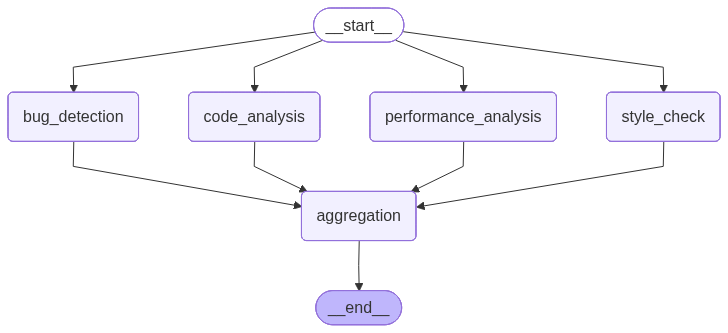

In [10]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

## 7단계: 테스트 예제

실제 코드를 리뷰하는 예제입니다.


### 테스트 코드 준비


In [11]:
# 리뷰할 샘플 코드 (의도적으로 개선 여지가 있는 코드)
sample_code = """
def find_duplicates(list):
    result = []
    for i in range(len(list)):
        for j in range(len(list)):
            if i != j and list[i] == list[j]:
                if list[i] not in result:
                    result.append(list[i])
    return result

def calculate_average(numbers):
    sum = 0
    for n in numbers:
        sum = sum + n
    avg = sum / len(numbers)
    return avg

class userManager:
    def __init__(self):
        self.users = []
    
    def add_user(self, name, age):
        self.users.append({'name': name, 'age': age})
    
    def get_user(self, name):
        for user in self.users:
            if user['name'] == name:
                return user
        return None
"""

print("샘플 코드가 준비되었습니다.")


샘플 코드가 준비되었습니다.


### 코드 리뷰 실행


In [12]:
# 초기 상태 생성
initial_state = {
    "code": sample_code
}

# 그래프 실행 (병렬 실행)
result = app.invoke(initial_state)

[코드 분석 에이전트] 분석 완료
[성능 분석 에이전트] 분석 완료
[버그 검사 에이전트] 검사 완료
[스타일 검사 에이전트] 검사 완료
[통합 리포트 에이전트] 최종 리포트 생성 완료


### 개별 리뷰 결과 확인


In [13]:
for i, review in enumerate(result["reviews"], 1):
    print(f"\n리뷰 {i}:")
    print("-" * 80)
    print(review)
    print()



리뷰 1:
--------------------------------------------------------------------------------
[버그 검사]
## 전체적인 관점
아래 코드는 **기능은 동작**하지만, 실제 서비스·테스트·유지보수 단계에서 여러 종류의 버그·취약점을 만들 수 있습니다.  
다음 항목을 기준으로 문제를 정리하고, 각각에 대한 **구체적인 수정·보완 방안**을 제시합니다.

| 구분 | 코드 위치 | 주요 문제 | 위험도(1‑5) | 권고 사항 |
|------|-----------|-----------|------------|-----------|
| 1️⃣ | `find_duplicates` | *내장 이름 `list`와 `sum`을 파라미터·변수명으로 사용* → 가독성 저하·예상치 못한 오버라이드 | 3 | 파라미터·변수명을 다른 이름(`items`, `total`)으로 바꾸기 |
| 2️⃣ | `find_duplicates` | **시간 복잡도 O(n²)** – 큰 리스트에서 성능 급락 | 4 | `set`·`dict`를 이용해 O(n) 구현 |
| 3️⃣ | `find_duplicates` | **중복 검사 로직이 비대칭** – `i != j` 조건만으로는 같은 값이 여러 번 비교돼 불필요한 연산 발생 | 2 | `j`를 `i+1`부터 시작하도록 바꾸면 중복 비교를 한 번만 수행 |
| 4️⃣ | `calculate_average` | **빈 리스트**에 대해 `len(numbers) == 0` → `ZeroDivisionError` | 5 | 입력 검증·예외 처리 추가 |
| 5️⃣ | `calculate_average` | `sum`이라는 변수명이 파이썬 내장 함수 `sum()`을 가리켜 **덮어쓰기** → 이후 `sum()` 사용 불가 | 3 | 변수명을 `total` 등으로 변경 |
| 6️⃣ | `calculate_average` | **숫자가 아닌 요소**(예: `None`, `str`)가 들어오면 

### 통합 리포트 확인


In [14]:
print(result["final_report"])

## 📋 최종 코드 리뷰 리포트  
(버그·성능·스타일 3명의 전문가 의견을 종합)

---

### 1️⃣ 주요 발견 사항 요약  

| 영역 | 핵심 문제 | 위험도(1‑5) | 현재 코드 품질 |
|------|-----------|------------|----------------|
| **네이밍·스코프** | `list`, `sum` 등 파이썬 내장 이름을 파라미터·변수명으로 사용 → 가독성 저하·예상치 못한 오버라이드 | 3 | **낮음** – 충돌 위험이 높음 |
| **시간 복잡도** | `find_duplicates`가 O(n²) 이중 루프 사용 | 4 | **낮음** – 대용량 데이터에서 심각한 성능 저하 |
| **불필요한 중복 비교** | `i != j` 로 양방향 비교 → 동일 쌍을 두 번 검사 | 2 | **보통** |
| **예외·입력 검증 부재** | `calculate_average` 빈 리스트 시 `ZeroDivisionError`, 비숫자 요소 시 `TypeError` | 5 | **낮음** |
| **클래스 네이밍·구조** | `userManager`가 PEP‑8 위반, 내부 `users` 를 리스트로 관리해 O(m) 조회 | 3 | **보통** |
| **문서·타입 힌트 부재** | 함수·클래스에 docstring·type hint가 없음 → IDE·정적 분석 활용 어려움 | 2 | **보통** |
| **모듈·패키지 구조** | 모든 코드가 단일 파일에 섞여 있어 재사용·테스트·확장성이 낮음 | 2 | **보통** |

> **전체적인 코드 품질** : **C‑등급** (동작은 하지만 유지보수·확장·안정성 측면에서 개선이 시급함)

---

### 2️⃣ 우선순위별 개선 사항 정리  

| 우선순위 | 개선 항목 | 구체적인 조치 | 기대 효과 |
|----------|-----------|---------------|-----------|
| **P1 (가장 시급)** | 1️⃣ **예외·입력 검증** – `calcu